In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [3]:
# Loading and handling dataset

# Read the file manually line-by-line
with open("Assignment_Data.csv", encoding="utf-8") as f:
    lines = f.readlines()

# Strip newline characters and split each line by semicolon
split_lines = [line.strip().split(";") for line in lines]

# Convert to DataFrame
df = pd.DataFrame(split_lines[1:], columns=split_lines[0])  # first line is header


In [5]:
# Preview
print(df.head())

  ﻿BillNo                             Itemname Quantity              Date  \
0  536365   WHITE HANGING HEART T-LIGHT HOLDER        6  01.12.2010 08:26   
1  536365                  WHITE METAL LANTERN        6  01.12.2010 08:26   
2  536365       CREAM CUPID HEARTS COAT HANGER        8  01.12.2010 08:26   
3  536365  KNITTED UNION FLAG HOT WATER BOTTLE        6  01.12.2010 08:26   
4  536365       RED WOOLLY HOTTIE WHITE HEART.        6  01.12.2010 08:26   

  Price CustomerID         Country  
0  2,55      17850  United Kingdom  
1  3,39      17850  United Kingdom  
2  2,75      17850  United Kingdom  
3  3,39      17850  United Kingdom  
4  3,39      17850  United Kingdom  


### **Preprocessing Data**

In [6]:
# Dataset shape
print(f"Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")
# Dataset
print("\nFirst 5 rows:")
print(df.head())
# Columns in dataset
print("\nColumns:")
print(df.columns)
# Dataset Information
print("\nInfo:")
print(df.info)
# Datatypes in dataset
print("\nData Types:")
print(df.dtypes)
# Column Structure
print("\nColumn Structure:")
print(df.columns.tolist())
# Missing values in dataset
print("\nMissing Values:")
print(df.isnull().sum())
# Description of dataset
print("\nDescription:")
print(df.describe())

Shape: (522064, 7) (Rows: 522064, Columns: 7)

First 5 rows:
  ﻿BillNo                             Itemname Quantity              Date  \
0  536365   WHITE HANGING HEART T-LIGHT HOLDER        6  01.12.2010 08:26   
1  536365                  WHITE METAL LANTERN        6  01.12.2010 08:26   
2  536365       CREAM CUPID HEARTS COAT HANGER        8  01.12.2010 08:26   
3  536365  KNITTED UNION FLAG HOT WATER BOTTLE        6  01.12.2010 08:26   
4  536365       RED WOOLLY HOTTIE WHITE HEART.        6  01.12.2010 08:26   

  Price CustomerID         Country  
0  2,55      17850  United Kingdom  
1  3,39      17850  United Kingdom  
2  2,75      17850  United Kingdom  
3  3,39      17850  United Kingdom  
4  3,39      17850  United Kingdom  

Columns:
Index(['﻿BillNo', 'Itemname', 'Quantity', 'Date', 'Price', 'CustomerID',
       'Country'],
      dtype='object')

Info:
<bound method DataFrame.info of        ﻿BillNo                             Itemname Quantity  \
0       536365   WHITE HANG

In [8]:
# Clean column names
df.columns = df.columns.str.strip().str.replace('﻿', '')

In [10]:
# Handle missing values
df = df.dropna(subset=['BillNo', 'Itemname'])
df['CustomerID'] = df['CustomerID'].fillna('Unknown')

In [11]:
# Filter to single country (optional)
df = df[df['Country'] == 'United Kingdom']

In [12]:
# Clean item names
df['Itemname'] = df['Itemname'].str.strip().str.lower()

In [13]:
# Create transaction dataset
transactions = df.groupby('BillNo')['Itemname'].apply(list).reset_index(name='Items')
transaction_list = transactions['Items'].tolist()

In [14]:
# Encode transactions
encoder = TransactionEncoder()
encoded_data = encoder.fit(transaction_list).transform(transaction_list)
transaction_df = pd.DataFrame(encoded_data, columns=encoder.columns_)

print(f"\nEncoded transactions shape: {transaction_df.shape}")
print(f"\nSample transactions:\n{transaction_df.head()}")


Encoded transactions shape: (20122, 4159)

Sample transactions:
          "assorted flower colour ""leis"""  \
0  False                              False   
1  False                              False   
2  False                              False   
3  False                              False   
4  False                              False   

   "charlie+lola""extremely busy"" sign"  \
0                                  False   
1                                  False   
2                                  False   
3                                  False   
4                                  False   

   "flower glass garland neckl.36""black"  \
0                                   False   
1                                   False   
2                                   False   
3                                   False   
4                                   False   

   "flower glass garland neckl.36""blue"  \
0                                  False   
1                           

### **Frequent Itemset Generation with Apriori**

In [15]:
# Generate frequent itemsets
frequent_itemsets = apriori(
    transaction_df,
    min_support=0.02,  # Adjust based on data density
    use_colnames=True
)

# Sort and inspect
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)
print(f"\nTop 10 frequent itemsets:\n{frequent_itemsets.head(10)}")


Top 10 frequent itemsets:
      support                              itemsets
228  0.107643  (white hanging heart t-light holder)
89   0.096312             (jumbo bag red retrospot)
172  0.083739            (regency cakestand 3 tier)
141  0.079217                       (party bunting)
0    0.072309                                    ()
114  0.069178             (lunch bag red retrospot)
12   0.068134       (assorted colour bird ornament)
187  0.061674    (set of 3 cake tins pantry design)
124  0.060580      (natural slate heart chalkboard)
107  0.060431             (lunch bag  black skull.)


### **Association Rule Mining**

In [16]:
# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

In [17]:
# Add additional metrics
rules['leverage'] = rules['support'] - (rules['antecedent support'] * rules['consequent support'])
rules['conviction'] = (1 - rules['antecedent support']) / (1 - rules['confidence'])

In [18]:
# Sort by business relevance
rules = rules.sort_values(['lift', 'confidence'], ascending=False)
print(f"\nTop association rules:\n{rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()}")


Top association rules:
                                          antecedents  \
49  (green regency teacup and saucer, roses regenc...   
52                   (pink regency teacup and saucer)   
50  (roses regency teacup and saucer, pink regency...   
51                  (green regency teacup and saucer)   
48  (green regency teacup and saucer, pink regency...   

                                          consequents   support  confidence  \
49                   (pink regency teacup and saucer)  0.024501    0.703281   
52  (green regency teacup and saucer, roses regenc...  0.024501    0.701280   
50                  (green regency teacup and saucer)  0.024501    0.902930   
51  (roses regency teacup and saucer, pink regency...  0.024501    0.527837   
48                  (roses regency teacup and saucer)  0.024501    0.854419   

         lift  
49  20.130044  
52  20.130044  
50  19.452640  
51  19.452640  
48  17.965128  


### **Rule Evaluation and Visualization**

In [19]:
# Filter actionable rules
actionable_rules = rules[
    (rules['lift'] > 1.5) &
    (rules['confidence'] > 0.4) &
    (rules['consequents'].apply(len) == 1)
].copy()

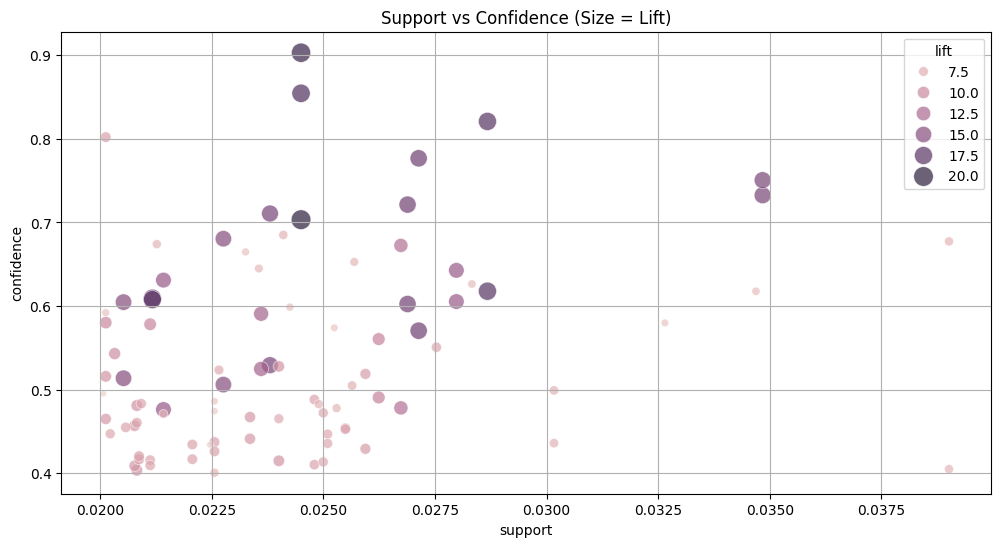

In [20]:
# Visualize relationships
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=actionable_rules,
    x='support',
    y='confidence',
    size='lift',
    hue='lift',
    sizes=(20, 200),
    alpha=0.7
)
plt.title('Support vs Confidence (Size = Lift)')
plt.grid()
plt.show()

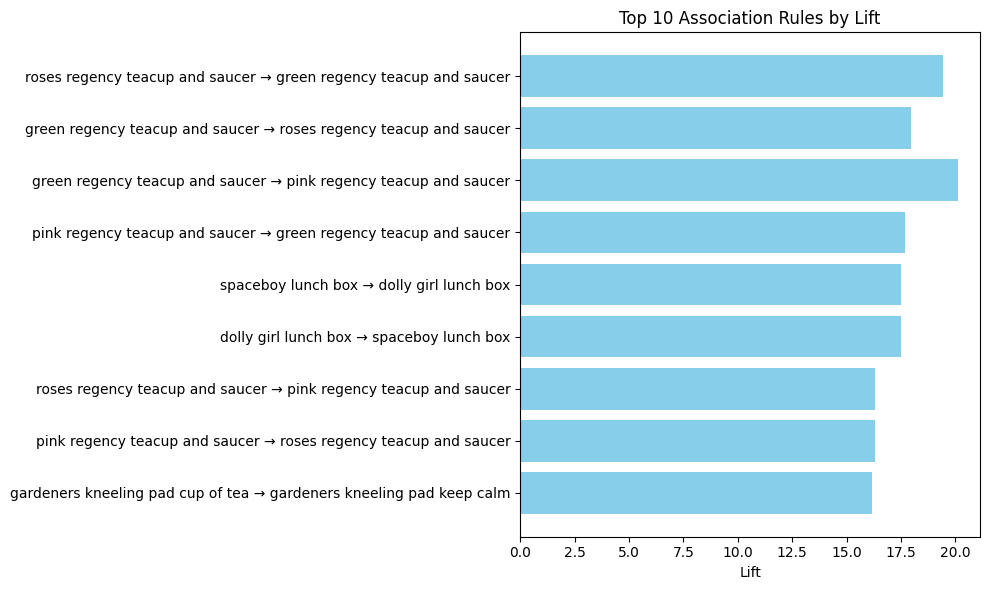

In [21]:
# Plot top 10 rules by lift
top_rules = actionable_rules.head(10).sort_values('lift', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(
    y=[f"{list(x)[0]} → {list(y)[0]}" for x,y in zip(top_rules['antecedents'], top_rules['consequents'])],
    width=top_rules['lift'],
    color='skyblue'
)
plt.xlabel('Lift')
plt.title('Top 10 Association Rules by Lift')
plt.tight_layout()
plt.show()

### **Interpretation and Practical Applications**

In [22]:
# Analyze top 5 actionable rules
for idx, row in actionable_rules.head(5).iterrows():
    antecedent = ', '.join(list(row['antecedents']))
    consequent = list(row['consequents'])[0]

    print(f"\nRule #{idx+1}:")
    print(f"When customers buy {antecedent}, they're {row['confidence']*100:.1f}% likely to buy {consequent}")
    print(f"- Lift: {row['lift']:.2f} (Rule is {row['lift']:.1f}x more effective than random)")
    print(f"- Support: {row['support']:.3f} (Occurs in {row['support']*100:.1f}% of transactions)")

    # Business recommendations
    recommendations = [
        f"Place '{consequent}' near '{antecedent}' sections",
        f"Bundle products: Create '{antecedent} + {consequent}' promotion",
        f"Cross-sell '{consequent}' on product pages for {antecedent}",
        f"Stock extra {consequent} when running promotions on {antecedent}"
    ]

    print("\nRecommended actions:")
    for i, rec in enumerate(recommendations, 1):
        print(f"{i}. {rec}")


Rule #50:
When customers buy green regency teacup and saucer, roses regency teacup and saucer, they're 70.3% likely to buy pink regency teacup and saucer
- Lift: 20.13 (Rule is 20.1x more effective than random)
- Support: 0.025 (Occurs in 2.5% of transactions)

Recommended actions:
1. Place 'pink regency teacup and saucer' near 'green regency teacup and saucer, roses regency teacup and saucer' sections
2. Bundle products: Create 'green regency teacup and saucer, roses regency teacup and saucer + pink regency teacup and saucer' promotion
3. Cross-sell 'pink regency teacup and saucer' on product pages for green regency teacup and saucer, roses regency teacup and saucer
4. Stock extra pink regency teacup and saucer when running promotions on green regency teacup and saucer, roses regency teacup and saucer

Rule #51:
When customers buy roses regency teacup and saucer, pink regency teacup and saucer, they're 90.3% likely to buy green regency teacup and saucer
- Lift: 19.45 (Rule is 19.5x m

In [23]:
# Generate insights report
print("\n" + "="*50)
print("Key Strategic Insights:")
print("="*50)
print(f"1. Most influential product: {frequent_itemsets.iloc[0]['itemsets']}")
print(f"2. Highest lift association: {top_rules.iloc[0]['antecedents']} → {top_rules.iloc[0]['consequents']} (Lift: {top_rules.iloc[0]['lift']:.2f})")
print(f"3. Most reliable rule: Confidence = {actionable_rules['confidence'].max()*100:.1f}%")
print("4. Potential bundle opportunities:")
for itemset in frequent_itemsets[frequent_itemsets['itemsets'].apply(len) > 1].head(3)['itemsets']:
    print(f"   - {', '.join(list(itemset))}")


Key Strategic Insights:
1. Most influential product: frozenset({'white hanging heart t-light holder'})
2. Highest lift association: frozenset({'gardeners kneeling pad cup of tea'}) → frozenset({'gardeners kneeling pad keep calm'}) (Lift: 16.16)
3. Most reliable rule: Confidence = 90.3%
4. Potential bundle opportunities:
   - jumbo bag pink polkadot, jumbo bag red retrospot
   - green regency teacup and saucer, roses regency teacup and saucer
   - jumbo storage bag suki, jumbo bag red retrospot
